In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct


import funciones_aux as fau

import funciones_dsa as fun_dsa
import funciones_dsa_unilateral as fun_dsa_u
import funciones_dsa_bilateral as fun_dsa_b

import funciones_plot_dsa as fun_plot

from scipy.signal import welch
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.stats import pearsonr, spearmanr


# 1. Unilateral

In [2]:
ruta_fa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.f_a"
ruta_spa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
ruta_ha_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a"
ruta_ta_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.t_a"

archivo_r2a = r"C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

## 1. 1.  Archivo Espectral .f_a

In [3]:
tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa_unilat, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz


## 1. 2. Archivo variables procesadas .spa

In [4]:
df_spa_raw = fau.procesar_spa(ruta_spa_unilat)
df_spa_unilat = fun_dsa_u.limpiar_spa_unilateral(df_spa_raw)

print("Dimensiones del archivo procesado:", df_spa_unilat.shape)

Dimensiones del archivo procesado: (2119, 11)


### Fusión de los anteriores

In [5]:
df_merge_fa = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_fa["SEF08"]
mf_hor = df_merge_fa["MEDFRQ08"]

dsa_plot_fa, mask_total_fa = fun_dsa.preparar_dsa_con_mask(tiempo_fa_unilat, dsa_unilat, df_merge_fa)


### Cabecera

In [6]:
num_canales, fs, pendiente, offset = fau.extraer_parametros_eeg(ruta_ha_unilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales}")
print(f" - Frecuencia (Hz): {fs}")
print(f" - Pendiente (m): {pendiente:.8f}")
print(f" - Offset (b): {offset:.4f}")

Parámetros extraídos con éxito:
 - Canales: 2
 - Frecuencia (Hz): 128
 - Pendiente (m): 0.05000000
 - Offset (b): -3234.0000


## 1. 3 Archivo ondas crudas .r2a

In [7]:
df_eeg = fun_dsa_u.leer_r2a(
    archivo_r2a,
    pendiente,
    offset,
    fs=fs
)



# 2. Bilateral - Advanced

In [8]:
ruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.f_a"
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.r4a" 

In [9]:
"""
ruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.f_a"
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.r4a" 
"""

'\nruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.f_a"\nruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.spa"\nruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.h_a"\nruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.t_a"\n\narchivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.r4a" \n'

In [10]:
"""
# este es para el bis vista que no tiene fa
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.h_a"
ruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.t_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.r4a"
"""

'\n# este es para el bis vista que no tiene fa\nruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.spa"\nruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.h_a"\nruta_ta_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.t_a"\n\narchivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_antiguo/L04141330/L04141330.r4a"\n'

## 2. 1. Archivo Espectral .f_a

In [11]:
tiempo_fa_bilat, dsa_fa_L, dsa_fa_R = fau.cargar_fa_bilateral(
    ruta_fa_bilat,
    escalar_db=True
)

print("Dimensiones del archivo hemisferio izquierdo:", dsa_fa_L.shape)
print("Dimensiones del archivo hemisferio derecho:", dsa_fa_R.shape)

Dimensiones del archivo hemisferio izquierdo: (60890, 60)
Dimensiones del archivo hemisferio derecho: (60890, 60)


## 2. 2. Archivo variables procesadas .spa

In [12]:
df_spa_raw_bilat = fau.procesar_spa(ruta_spa_bilat)
df_spa_bilat = fun_dsa_b.limpiar_spa_bilateral(df_spa_raw_bilat)

print("Dimensiones del archivo procesado:", df_spa_bilat.shape)
print(df_spa_bilat.columns.tolist())
display(df_spa_bilat.head())

Dimensiones del archivo procesado: (60889, 32)
['Time', 'SpSmooth', 'SR12_izq', 'SEF08_izq', 'MEDFRQ08_izq', 'BISBIT00_izq', 'DB13U01_izq', 'DB11U04_izq', 'B34U05_izq', 'TOTPOW08_izq', 'EMGLOW01_izq', 'SQI10_izq', 'IMPEDNCE_izq', 'ARTF2_izq', 'BURST_izq', 'ST_izq', 'SR12_der', 'SEF08_der', 'MEDFRQ08_der', 'BISBIT00_der', 'DB13U01_der', 'DB11U04_der', 'B34U05_der', 'TOTPOW08_der', 'EMGLOW01_der', 'SQI10_der', 'IMPEDNCE_der', 'ARTF2_der', 'BURST_der', 'ST_der', 'ASYM09', 'modo_spa']


,Time,SpSmooth,SR12_izq,SEF08_izq,MEDFRQ08_izq,BISBIT00_izq,DB13U01_izq,DB11U04_izq,B34U05_izq,TOTPOW08_izq,...,B34U05_der,TOTPOW08_der,EMGLOW01_der,SQI10_der,IMPEDNCE_der,ARTF2_der,BURST_der,ST_der,ASYM09,modo_spa
0,2026-04-30 19:23:29,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,34.0,0.0,3.7,2000000.0,NaN,32768.0,NaN,bilateral
1,2026-04-30 19:23:30,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,24.6,0.0,3.7,0.0,NaN,32768.0,NaN,bilateral
2,2026-04-30 19:23:31,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,24.2,0.8,3.8,0.0,NaN,32768.0,NaN,bilateral
3,2026-04-30 19:23:32,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,24.8,2.5,3.7,20.0,NaN,1.0,NaN,bilateral
4,2026-04-30 19:23:33,3,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,...,NaN,NaN,25.1,4.2,3.8,NaN,NaN,2.0,NaN,bilateral


### timeline oficial del .spa

In [13]:
timeline_spa_bilat = fun_dsa_b.preparar_timeline_spa(
    df_spa=df_spa_bilat,
    columna_time="Time",
    resolver_duplicados="last",
    verbose=True
)

Aviso: el .spa contiene 80 tiempos duplicados. Estrategia usada: last.
=== Timeline .spa ===
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
N segundos .spa: 60809


### ajustar .f_a a la timeline del .spa

In [14]:
dsa_fa_L_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_fa_bilat,
    dsa=dsa_fa_L,
    timeline_spa=timeline_spa_bilat,
    nombre="f_a izquierdo",
    verbose=True
)

dsa_fa_R_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_fa_bilat,
    dsa=dsa_fa_R,
    timeline_spa=timeline_spa_bilat,
    nombre="f_a derecho",
    verbose=True
)


Aviso f_a izquierdo: hay tiempos duplicados. Se conserva el último.
=== Ajuste f_a izquierdo a timeline .spa ===
Inicio DSA original: 2026-04-30 19:23:28
Fin DSA original: 2026-05-01 12:18:16
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Filas DSA original: 60810
Filas timeline .spa: 60809
Filas DSA ajustada: 60809
Filas completamente NaN: 0
Aviso f_a derecho: hay tiempos duplicados. Se conserva el último.
=== Ajuste f_a derecho a timeline .spa ===
Inicio DSA original: 2026-04-30 19:23:28
Fin DSA original: 2026-05-01 12:18:16
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Filas DSA original: 60810
Filas timeline .spa: 60809
Filas DSA ajustada: 60809
Filas completamente NaN: 0


### Extraer .spa para cada hemisferio 

In [15]:
df_spa_L = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="izq",
    verbose=False
)

df_spa_R = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="der",
    verbose=False
)

###  Fusión .f_a y .spa

In [16]:
"""
Si hay dos paquetes con el mismo segundo, conservar el último suele ser razonable porque representa el estado más reciente dentro de ese segundo.

No usaría mean como opción principal porque hay columnas que no son realmente promediables
"""

df_merge_fa_L = fun_dsa.alinear_spa_con_tiempo(
    timeline_spa_bilat,
    df_spa_L,
    resolver_duplicados="last"
)dsa_

df_merge_fa_R = fun_dsa.alinear_spa_con_tiempo(
    timeline_spa_bilat,
    df_spa_R,
    resolver_duplicados="last"
)

# Curvas del BIS por hemisferio
sef_fa_L = df_merge_fa_L["SEF08"]
mef_fa_L = df_merge_fa_L["MEDFRQ08"]

sef_fa_R = df_merge_fa_R["SEF08"]
mef_fa_R = df_merge_fa_R["MEDFRQ08"]

Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.
Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.


In [17]:
print("timeline_spa_bilat:", len(timeline_spa_bilat))
print("df_merge_fa_L:", df_merge_fa_L.shape)
print("df_merge_fa_R:", df_merge_fa_R.shape)

timeline_spa_bilat: 60809
df_merge_fa_L: (60809, 9)
df_merge_fa_R: (60809, 9)


### Cabecera

In [22]:
num_canales_bil, fs_bil, pendiente_bil, offset_bil = fau.extraer_parametros_eeg(ruta_ha_bilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales_bil}")
print(f" - Frecuencia (Hz): {fs_bil}")
print(f" - Pendiente (m): {pendiente_bil:.8f}")
print(f" - Offset (b): {offset_bil:.4f}")

Parámetros extraídos con éxito:
 - Canales: 4
 - Frecuencia (Hz): 128
 - Pendiente (m): 0.05000000
 - Offset (b): -3234.0000


## 2. 3. Archivo ondas crudas .r4a

In [23]:
df_eeg_bilateral = fun_dsa_b.leer_r4a(
    archivo_r4a, 
    pendiente_bil,
    offset_bil, 
    fs=fs_bil)

In [24]:
# Alinear raw al tamaño y timeline del .spa
df_eeg_bilat_recortado, timeline_spa_bilat, info_alineacion = (
    fun_dsa_b.recortar_raw_segun_ta_y_spa(
        df_raw=df_eeg_bilateral,
        ruta_ta=ruta_ta_bilat,
        df_spa=df_spa_bilat,
        columna_time="Time",
        fs=fs_bil,
        resolver_duplicados="last",
        verbose=True
    )
)

# Usar el inicio del .spa como inicio de la DSA reconstruida
hora_inicio = timeline_spa_bilat.iloc[0]

print("Raw bilateral original:", df_eeg_bilateral.shape)
print("Raw bilateral recortado:", df_eeg_bilat_recortado.shape)
print("Timeline SPA:", len(timeline_spa_bilat))

Aviso: el .spa contiene 80 tiempos duplicados. Estrategia usada: last.
=== Timeline .spa ===
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
N segundos .spa: 60809
=== Alineación raw a timeline .spa ===
Inicio raw (.t_a): 2026-04-30 19:23:28
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Desfase spa - raw: 1.0 s
Acción inicio: recorte_inicio
Segundos objetivo .spa: 60809
Muestras objetivo: 7783552
Muestras raw originales: 7793920
Muestras recortadas inicio: 128
Muestras NaN inicio: 0
Muestras recortadas final: 0
Muestras NaN final: 0
Muestras raw alineado: 7783552
Duración raw alineado: 60809.0 s
Raw bilateral original: (7793920, 9)
Raw bilateral recortado: (7783552, 9)
Timeline SPA: 60809


### 2. 3. 1. Reconstrucción

In [25]:
# ============================================================
# Reconstrucción DSA por canal
# ============================================================

ventana_welch_s = 1
paso_welch_s = 1

df_dsa_canal1, frecuencias_c1 = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_1_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="inicio"
)

df_dsa_canal2, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_2_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="inicio"
)

df_dsa_canal3, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_3_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="inicio"
)

df_dsa_canal4, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilat_recortado,
    "canal_4_uV",
    fs=fs_bil,
    ventana_seg=ventana_welch_s,
    paso_seg=paso_welch_s,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="inicio"
)

In [26]:
# Combinación por hemisferio en escala lineal

cols_freq = [c for c in df_dsa_canal1.columns if c != "tiempo_s"]

# Izquierda: canal 1 + canal 2
pot_media_izq = (
    df_dsa_canal1[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal2[cols_freq].to_numpy(dtype=float)
) / 2

# Derecha: canal 3 + canal 4
pot_media_der = (
    df_dsa_canal3[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal4[cols_freq].to_numpy(dtype=float)
) / 2

df_dsa_izq = df_dsa_canal1.copy()
df_dsa_der = df_dsa_canal3.copy()

In [27]:
# Conversión a dB para visualización

ref_potencia = 0.0001

df_dsa_izq[cols_freq] = 10 * np.log10(
    (pot_media_izq + 1e-12) / (ref_potencia ** 2)
)

df_dsa_der[cols_freq] = 10 * np.log10(
    (pot_media_der + 1e-12) / (ref_potencia ** 2)
)

### 2. 3. 2. Adaptación temporal, máscara y plot de DSA EEG

In [28]:
# ============================================================
# Adaptación temporal inicial de la DSA reconstruida
# ============================================================

hora_inicio = timeline_spa_bilat.iloc[0]

tiempo_eeg_bilat_tmp, dsa_eeg_izq_tmp = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_izq,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

_, dsa_eeg_der_tmp = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_der,
    frecuencias=frecuencias_c1,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=False
)

In [29]:
# ============================================================
# Ajustar reconstruida a la timeline oficial del .spa
# ============================================================

dsa_eeg_izq_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_eeg_bilat_tmp,
    dsa=dsa_eeg_izq_tmp,
    timeline_spa=timeline_spa_bilat,
    nombre="DSA EEG reconstruida izquierda",
    verbose=True
)

dsa_eeg_der_spa = fun_dsa_b.ajustar_dsa_a_timeline_spa(
    tiempo_dsa=tiempo_eeg_bilat_tmp,
    dsa=dsa_eeg_der_tmp,
    timeline_spa=timeline_spa_bilat,
    nombre="DSA EEG reconstruida derecha",
    verbose=True
)

# Desde aquí, el tiempo oficial de la reconstruida también es el del .spa
tiempo_eeg_bilat = timeline_spa_bilat.copy()

=== Ajuste DSA EEG reconstruida izquierda a timeline .spa ===
Inicio DSA original: 2026-04-30 19:23:29
Fin DSA original: 2026-05-01 12:16:57
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Filas DSA original: 60809
Filas timeline .spa: 60809
Filas DSA ajustada: 60809
Filas completamente NaN: 79
=== Ajuste DSA EEG reconstruida derecha a timeline .spa ===
Inicio DSA original: 2026-04-30 19:23:29
Fin DSA original: 2026-05-01 12:16:57
Inicio .spa: 2026-04-30 19:23:29
Fin .spa: 2026-05-01 12:18:16
Filas DSA original: 60809
Filas timeline .spa: 60809
Filas DSA ajustada: 60809
Filas completamente NaN: 79


In [30]:
# Merge del .spa para la reconstruida

df_merge_eeg_izq = fun_dsa.alinear_spa_con_tiempo(
    tiempo=timeline_spa_bilat,
    df_spa=df_spa_L,
    resolver_duplicados="last"
)

df_merge_eeg_der = fun_dsa.alinear_spa_con_tiempo(
    tiempo=timeline_spa_bilat,
    df_spa=df_spa_R,
    resolver_duplicados="last"
)

Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.
Aviso: se han encontrado 80 tiempos duplicados en el .spa. Estrategia usada: last.


### Máscaras de calidad bilateral - común

In [72]:
_, mask_eeg_L = fun_dsa.preparar_dsa_con_mask(
    tiempo=timeline_spa_bilat,
    dsa=dsa_eeg_izq_spa,
    df_merge=df_merge_eeg_izq,
    umbral_sqi=15,
    umbral_ceros=0.9
)

_, mask_eeg_R = fun_dsa.preparar_dsa_con_mask(
    tiempo=timeline_spa_bilat,
    dsa=dsa_eeg_der_spa,
    df_merge=df_merge_eeg_der,
    umbral_sqi=15,
    umbral_ceros=0.9
)


print(f"Filas totales izquierda:", len(mask_eeg_L))
print(f"Filas totales derecha:", len(mask_eeg_R))

print(f"\nFilas enmascaradas izquierda:", mask_eeg_L.sum())
print("Filas enmascaradas derecha:", mask_eeg_R.sum())

print(f"\nFilas válidas izquierda:", (~mask_eeg_L).sum())
print("Filas válidas derecha:", (~mask_eeg_R).sum())

Filas totales izquierda: 60809
Filas totales derecha: 60809

Filas enmascaradas izquierda: 3893
Filas enmascaradas derecha: 5288

Filas válidas izquierda: 56916
Filas válidas derecha: 55521


In [74]:
# -----------------------------------------------------------------------------------------------------

# Filas completamente NaN del .f_a ajustado al .spa (comprobación adicional por si acaso)
mask_fa_nan_L = dsa_fa_L_spa.isna().all(axis=1) 
mask_fa_nan_R = dsa_fa_R_spa.isna().all(axis=1)

mask_comun_L = mask_eeg_L | mask_fa_nan_L  
mask_comun_R = mask_eeg_R | mask_fa_nan_R  

print(f"\nFilas enmascaradas finales L:", mask_comun_L.sum())
print("Filas enmascaradas finales R:", mask_comun_R.sum())

print("\nNaN EEG L:", mask_eeg_nan_L.sum())
print("NaN EEG R:", mask_eeg_nan_R.sum())
print("NaN f_a L:", mask_fa_nan_L.sum())
print("NaN f_a R:", mask_fa_nan_R.sum())

print("\nFilas enmascaradas finales L:", mask_comun_L.sum())
print("Filas enmascaradas finales R:", mask_comun_R.sum())

print("\nFilas válidas finales L:", (~mask_comun_L).sum())
print("Filas válidas finales R:", (~mask_comun_R).sum())


Filas enmascaradas finales L: 3972
Filas enmascaradas finales R: 5367

NaN EEG L: 79
NaN EEG R: 79
NaN f_a L: 0
NaN f_a R: 0

Filas enmascaradas finales L: 3972
Filas enmascaradas finales R: 5367

Filas válidas finales L: 56837
Filas válidas finales R: 55442


In [79]:
# Aplicar máscara común para que izquierda y derecha tengan bandas blancas alineadas

# -------------------------------------- Para EEG ----------------------------------
dsa_eeg_izq_plot = dsa_eeg_izq_spa.copy()
dsa_eeg_der_plot = dsa_eeg_der_spa.copy()

dsa_eeg_izq_plot.loc[mask_comun_bilat.values, :] = np.nan
dsa_eeg_der_plot.loc[mask_comun_bilat.values, :] = np.nan

# -------------------------------------- Para FA ----------------------------------
dsa_plot_fa_L_mask = dsa_fa_L_spa.copy()
dsa_plot_fa_R_mask = dsa_fa_R_spa.copy()

dsa_plot_fa_L_mask.loc[mask_comun_bilat.values, :] = np.nan
dsa_plot_fa_R_mask.loc[mask_comun_bilat.values, :] = np.nan

In [84]:
mask_blanca_eeg_L = dsa_eeg_izq_plot.isna().all(axis=1)
mask_blanca_fa_L = dsa_plot_fa_L_mask.isna().all(axis=1)

mask_blanca_eeg_R = dsa_eeg_der_plot.isna().all(axis=1)
mask_blanca_fa_R = dsa_plot_fa_R_mask.isna().all(axis=1)

print("EEG L coincide con mask_comun_L:")
print((mask_blanca_eeg_L.values == mask_comun_L.values).all())

print("f_a L coincide con mask_comun_L:")
print((mask_blanca_fa_L.values == mask_comun_L.values).all())

print("\nEEG R coincide con mask_comun_R:")
print((mask_blanca_eeg_R.values == mask_comun_R.values).all())

print("f_a R coincide con mask_comun_R:")
print((mask_blanca_fa_R.values == mask_comun_R.values).all())

print("\nDiferencias EEG L:", (mask_blanca_eeg_L.values != mask_comun_L.values).sum())
print("Diferencias f_a L:", (mask_blanca_fa_L.values != mask_comun_L.values).sum())
print("Diferencias EEG R:", (mask_blanca_eeg_R.values != mask_comun_R.values).sum())
print("Diferencias f_a R:", (mask_blanca_fa_R.values != mask_comun_R.values).sum())

EEG L coincide con mask_comun_L:
True
f_a L coincide con mask_comun_L:
True

EEG R coincide con mask_comun_R:
True
f_a R coincide con mask_comun_R:
True

Diferencias EEG L: 0
Diferencias f_a L: 0
Diferencias EEG R: 0
Diferencias f_a R: 0


### 2. 3. 3. Preparar escala de color de f_a y eeg reconstruida

In [32]:
matriz_eeg_izq, matriz_eeg_der, vmin_eeg, vmax_eeg, norm_eeg_bilat, cmap_eeg_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_plot,
        dsa_eeg_der_plot,
        gamma=0.55
    )
)

print("Reconstruida bilateral")
print("vmin:", vmin_eeg)
print("vmax:", vmax_eeg)

Reconstruida bilateral
vmin: 51.953504739577234
vmax: 105.04946071021023


### 2. 3. 4. Visualizar reconstruidas desde .r4a

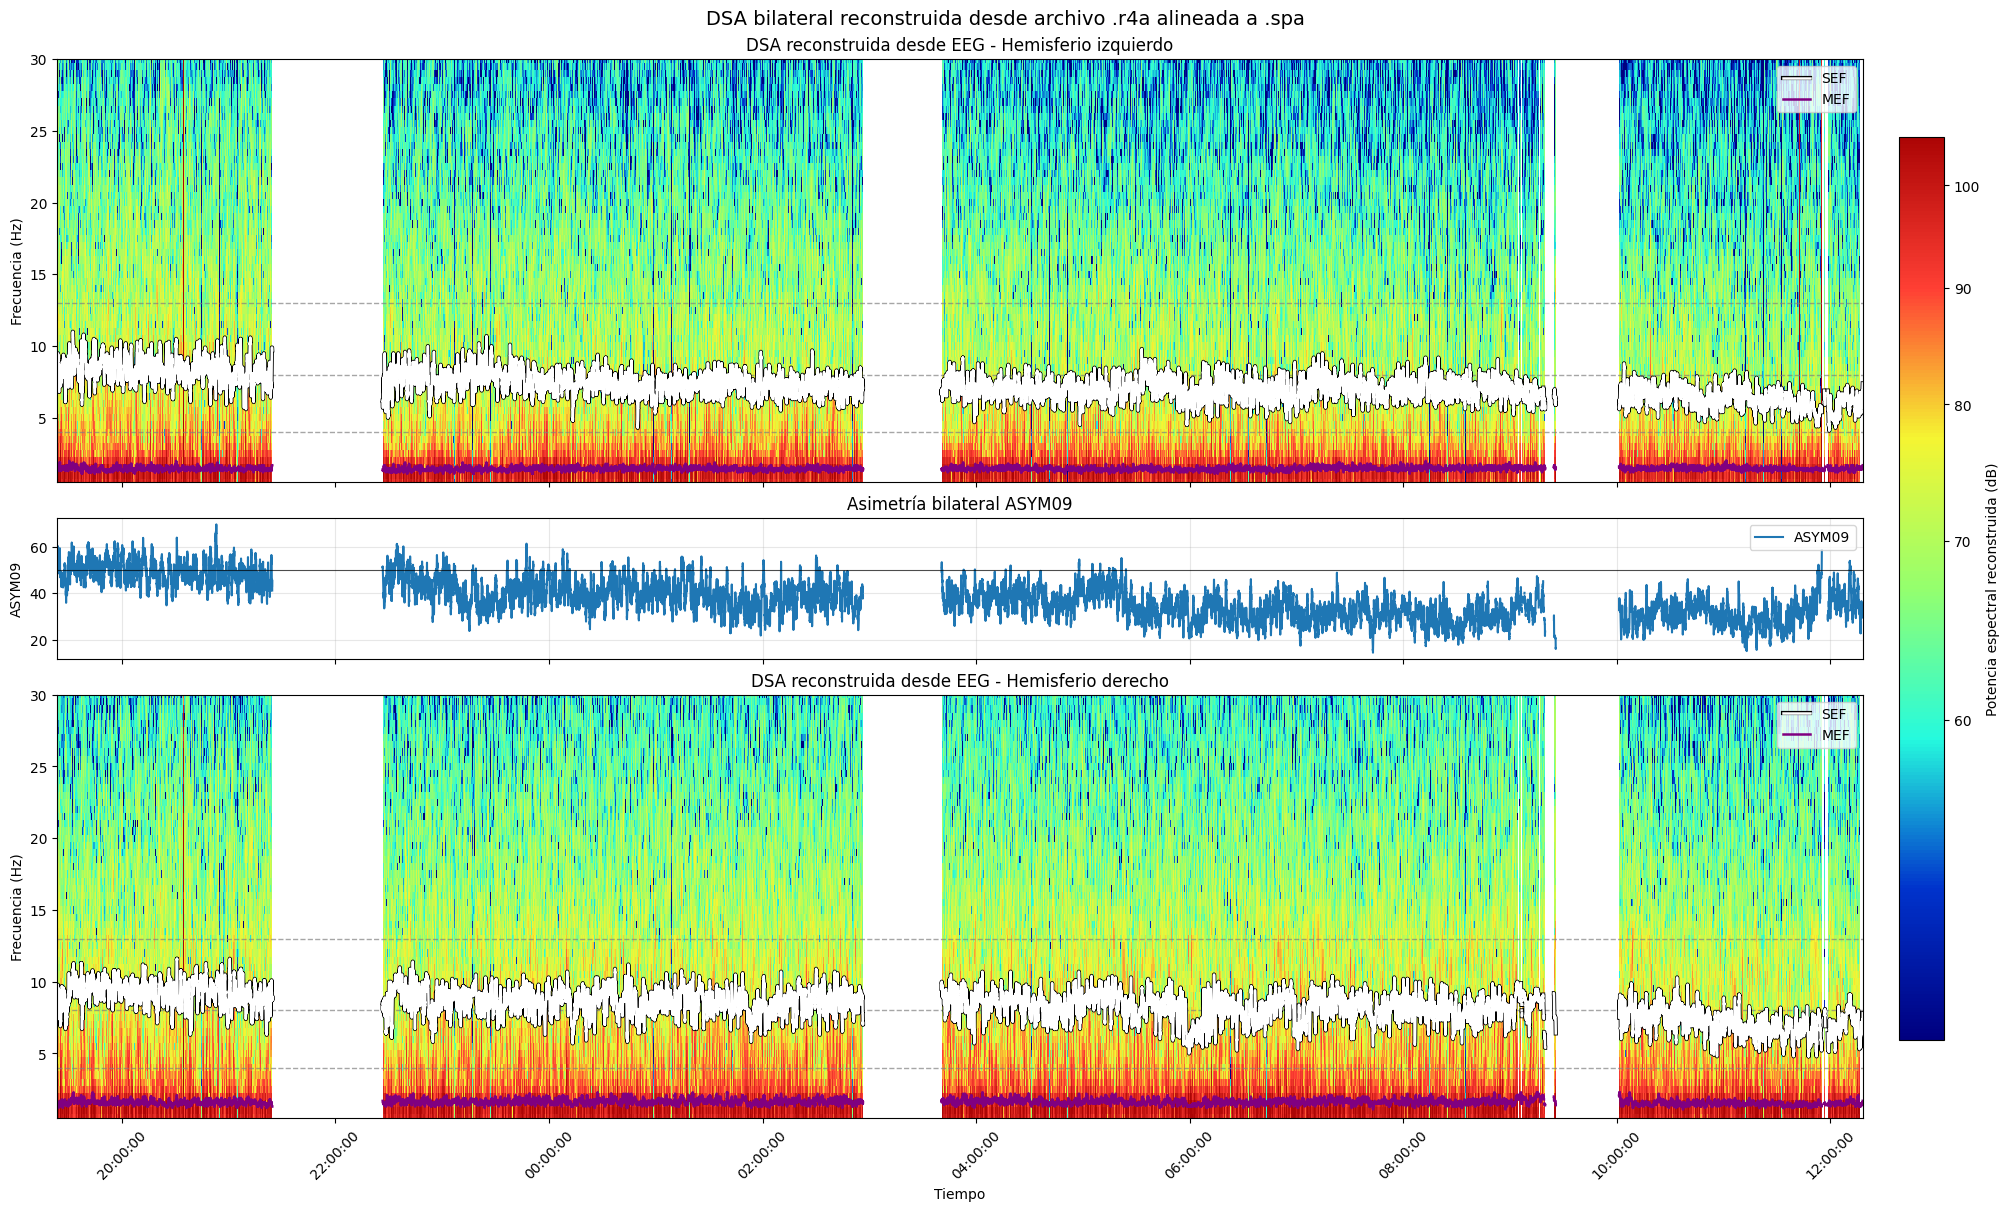

In [33]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=dsa_eeg_izq_plot.columns.astype(float),
    matriz_izq=matriz_eeg_izq,
    matriz_der=matriz_eeg_der,
    norm=norm_eeg_bilat,
    cmap=cmap_eeg_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_total_bilat,
    mask_der=mask_total_bilat,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida desde EEG - Hemisferio izquierdo",
    titulo_der="DSA reconstruida desde EEG - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde archivo .r4a alineada a .spa",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)"
)

### Máscaras y visualización - .f_a 

In [ ]:
# Escala de color común

frecuencias_fa = dsa_plot_fa_L_mask.columns.astype(float)

matriz_fa_L, matriz_fa_R, vmin_fa, vmax_fa, norm_fa_bilat, cmap_fa_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_plot_fa_L_mask,
        dsa_plot_fa_R_mask,
        vmin=49,
        vmax=94,
        gamma=1
    )
)

# Visualización

fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=frecuencias_fa,
    matriz_izq=matriz_fa_L,
    matriz_der=matriz_fa_R,
    norm=norm_fa_bilat,
    cmap=cmap_fa_bilat,
    df_merge_izq=df_merge_fa_L,
    df_merge_der=df_merge_fa_R,
    mask_izq=mask_total_fa_bilat,
    mask_der=mask_total_fa_bilat,
    asimetria=df_merge_fa_L["ASYM09"],
    titulo_izq="DSA .f_a - Hemisferio izquierdo",
    titulo_der="DSA .f_a - Hemisferio derecho",
    titulo_general="DSA bilateral exportada en .f_a alineada a .spa",
    etiqueta_colorbar="Potencia espectral (dB)"
)

In [34]:
print("timeline_spa_bilat:", len(timeline_spa_bilat))

print("FA L ajustado:", dsa_fa_L_spa.shape)
print("FA R ajustado:", dsa_fa_R_spa.shape)

print("EEG L ajustado:", dsa_eeg_izq_spa.shape)
print("EEG R ajustado:", dsa_eeg_der_spa.shape)

print("merge EEG L:", df_merge_eeg_izq.shape)
print("merge EEG R:", df_merge_eeg_der.shape)

print("plot EEG L:", dsa_eeg_izq_plot.shape)
print("plot EEG R:", dsa_eeg_der_plot.shape)

timeline_spa_bilat: 60809
FA L ajustado: (60809, 60)
FA R ajustado: (60809, 60)
EEG L ajustado: (60809, 60)
EEG R ajustado: (60809, 60)
merge EEG L: (60809, 9)
merge EEG R: (60809, 9)
plot EEG L: (60809, 60)
plot EEG R: (60809, 60)


In [35]:
cols_freq_eeg_L = [c for c in dsa_eeg_izq_plot.columns]

print("Mínimos y máximos hemisferio izquierdo - RECONSTRUCCIÓN")
print(np.nanmin(dsa_eeg_izq_plot[cols_freq_eeg_L].values))
print(np.nanmax(dsa_eeg_izq_plot[cols_freq_eeg_L].values))

print("Percentiles mínimos y máximos hemisferio izquierdo")
print(np.nanpercentile(dsa_eeg_izq_plot[cols_freq_eeg_L].values, 2))
print(np.nanpercentile(dsa_eeg_izq_plot[cols_freq_eeg_L].values, 99.5))

Mínimos y máximos hemisferio izquierdo - RECONSTRUCCIÓN
24.955712494443084
136.5202981634223
Percentiles mínimos y máximos hemisferio izquierdo
50.70895065370221
103.76228539095833


In [36]:
cols_freq_fa_L = [c for c in dsa_plot_fa_L_mask.columns]

print("Mínimos y máximos hemisferio izquierdo - FA")
print(np.nanmin(dsa_plot_fa_L_mask[cols_freq_fa_L].values))
print(np.nanmax(dsa_plot_fa_L_mask[cols_freq_fa_L].values))

print("Percentiles mínimos y máximos hemisferio izquierdo")
print(np.nanpercentile(dsa_plot_fa_L_mask[cols_freq_fa_L].values, 2))
print(np.nanpercentile(dsa_plot_fa_L_mask[cols_freq_fa_L].values, 99.5))

Mínimos y máximos hemisferio izquierdo - FA
35.25
97.08
Percentiles mínimos y máximos hemisferio izquierdo
52.53
91.24


In [37]:
cols_freq_eeg_R = [c for c in dsa_eeg_der_plot.columns]

print("Mínimos y máximos hemisferio derecho - RECONSTRUCCIÓN")
print(np.nanmin(dsa_eeg_der_plot[cols_freq_eeg_R].values))
print(np.nanmax(dsa_eeg_der_plot[cols_freq_eeg_R].values))

print("Percentiles mínimos y máximos hemisferio derecho")
print(np.nanpercentile(dsa_eeg_der_plot[cols_freq_eeg_R].values, 2))
print(np.nanpercentile(dsa_eeg_der_plot[cols_freq_eeg_R].values, 99.5))

Mínimos y máximos hemisferio derecho - RECONSTRUCCIÓN
27.20021403368633
136.8943006774285
Percentiles mínimos y máximos hemisferio derecho
53.897790700960066
105.75940507969912


In [38]:
cols_freq_fa_R = [c for c in dsa_plot_fa_R_mask.columns]

print("Mínimos y máximos hemisferio derecho - FA")
print(np.nanmin(dsa_plot_fa_R_mask[cols_freq_fa_R].values))
print(np.nanmax(dsa_plot_fa_R_mask[cols_freq_fa_R].values))

print("Percentiles mínimos y máximos hemisferio derecho")
print(np.nanpercentile(dsa_plot_fa_R_mask[cols_freq_fa_R].values, 2))
print(np.nanpercentile(dsa_plot_fa_R_mask[cols_freq_fa_R].values, 99.5))

Mínimos y máximos hemisferio derecho - FA
35.03
101.04
Percentiles mínimos y máximos hemisferio derecho
56.05
93.39


# Métricas y comparación



``` python

# Para métricas base:
dsa_eeg_izq_plot      vs dsa_plot_fa_L_mask
dsa_eeg_der_plot      vs dsa_plot_fa_R_mask

# Para suavizado:
dsa_eeg_izq_spa  vs  dsa_fa_L_spa
dsa_eeg_der_spa  vs  dsa_fa_R_spa

# Para visualizar:
tiempo = timeline_spa_bilat
```

In [39]:
# ============================================================
# Comparación base bilateral: EEG reconstruida vs .f_a
# ============================================================

# Izquierda
dsa_eeg_L_comp, dsa_fa_L_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_izq_plot,
    dsa_plot_fa_L_mask
)

dsa_eeg_L_z = fun_dsa.zscore_global(dsa_eeg_L_comp)
dsa_fa_L_z = fun_dsa.zscore_global(dsa_fa_L_comp)

metricas_base_L = fun_dsa.comparar_dsa_global(
    dsa_eeg_L_z,
    dsa_fa_L_z
)


# Derecha
dsa_eeg_R_comp, dsa_fa_R_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_der_plot,
    dsa_plot_fa_R_mask
)

dsa_eeg_R_z = fun_dsa.zscore_global(dsa_eeg_R_comp)
dsa_fa_R_z = fun_dsa.zscore_global(dsa_fa_R_comp)

metricas_base_R = fun_dsa.comparar_dsa_global(
    dsa_eeg_R_z,
    dsa_fa_R_z
)


# Resumen
# compara las matrices ya enmascaradas
df_metricas_base_bilat = pd.DataFrame([
    {"hemisferio": "izquierdo",
        **metricas_base_L},
    {"hemisferio": "derecho",
        **metricas_base_R}
])

display(df_metricas_base_bilat)

,hemisferio,n_valores_comparados,MAE,RMSE,bias_B_menos_A,Pearson,Spearman
0,izquierdo,3098340,0.413886,0.569470,0.000276,0.837831,0.802802
1,derecho,3098340,0.409272,0.540925,0.000196,0.853681,0.821133


In [40]:
# ============================================================
# Correlación por frecuencia bilateral
# ============================================================

df_corr_freq_L = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_L_z,
    dsa_fa_L_z
)

df_corr_freq_L["hemisferio"] = "izquierdo"


df_corr_freq_R = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_R_z,
    dsa_fa_R_z
)

df_corr_freq_R["hemisferio"] = "derecho"


df_corr_freq_bilat = pd.concat(
    [df_corr_freq_L, df_corr_freq_R],
    ignore_index=True
)

display(df_corr_freq_bilat.head())

,frecuencia_Hz,correlacion,hemisferio
0,0.5,0.080995,izquierdo
1,1.0,0.086268,izquierdo
2,1.5,0.082072,izquierdo
3,2.0,0.057399,izquierdo
4,2.5,0.044786,izquierdo


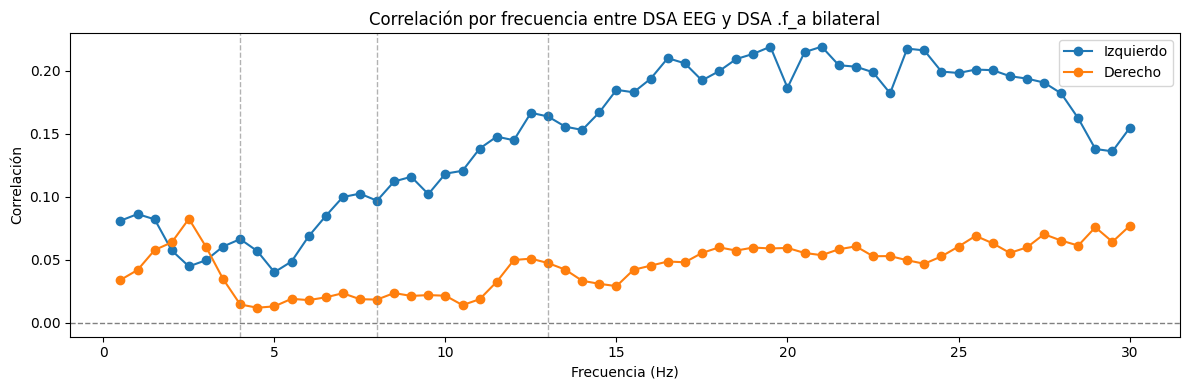

In [41]:
plt.figure(figsize=(12, 4))

plt.plot(
    df_corr_freq_L["frecuencia_Hz"],
    df_corr_freq_L["correlacion"],
    marker="o",
    label="Izquierdo"
)

plt.plot(
    df_corr_freq_R["frecuencia_Hz"],
    df_corr_freq_R["correlacion"],
    marker="o",
    label="Derecho"
)

for f in [4, 8, 13]:
    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Correlación")
plt.title("Correlación por frecuencia entre DSA EEG y DSA .f_a bilateral")
plt.legend()
plt.tight_layout()
plt.show()

### Suavizado + shift

In [42]:
# ============================================================
# Suavizado + shift bilateral
# Usar matrices alineadas a .spa, pero SIN máscara visual aplicada
# ============================================================

ventanas_sp_smooth = [5, 10, 30, 60]
shifts_prueba = range(-10, 30)

# Izquierda
dsa_eeg_L_shift_comp, dsa_fa_L_shift_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_izq_spa,
    dsa_fa_L_spa
)

df_suav_shift_L = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_L_shift_comp,
    dsa_fa_L_shift_comp,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=shifts_prueba
)

df_suav_shift_L = df_suav_shift_L.rename(columns={
    "Pearson": "Pearson_L",
    "Spearman": "Spearman_L",
    "MAE": "MAE_L",
    "RMSE": "RMSE_L"
})


# Derecha
dsa_eeg_R_shift_comp, dsa_fa_R_shift_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_der_spa,
    dsa_fa_R_spa
)

df_suav_shift_R = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_R_shift_comp,
    dsa_fa_R_shift_comp,
    ventanas_suavizado=ventanas_sp_smooth,
    shifts=shifts_prueba
)

df_suav_shift_R = df_suav_shift_R.rename(columns={
    "Pearson": "Pearson_R",
    "Spearman": "Spearman_R",
    "MAE": "MAE_R",
    "RMSE": "RMSE_R"
})


# Unir resultados
df_suav_shift_bilat = df_suav_shift_L.merge(
    df_suav_shift_R,
    on=["suavizado_s", "shift_s"],
    how="inner"
)

df_suav_shift_bilat["Pearson_medio"] = (
    df_suav_shift_bilat["Pearson_L"] +
    df_suav_shift_bilat["Pearson_R"]
) / 2

df_suav_shift_bilat["Spearman_medio"] = (
    df_suav_shift_bilat["Spearman_L"] +
    df_suav_shift_bilat["Spearman_R"]
) / 2

df_suav_shift_bilat["MAE_medio"] = (
    df_suav_shift_bilat["MAE_L"] +
    df_suav_shift_bilat["MAE_R"]
) / 2

df_suav_shift_bilat["RMSE_medio"] = (
    df_suav_shift_bilat["RMSE_L"] +
    df_suav_shift_bilat["RMSE_R"]
) / 2

display(
    df_suav_shift_bilat
    .sort_values("Pearson_medio", ascending=False)
    .head(10)
)

,suavizado_s,shift_s,Pearson_L,Spearman_L,MAE_L,RMSE_L,Pearson_R,Spearman_R,MAE_R,RMSE_R,Pearson_medio,Spearman_medio,MAE_medio,RMSE_medio
132,60,2,0.971692,0.973323,0.155192,0.237937,0.966179,0.966403,0.173179,0.260076,0.968936,0.969863,0.164186,0.249007
133,60,3,0.971695,0.973316,0.155224,0.237925,0.966173,0.966392,0.173196,0.260103,0.968934,0.969854,0.164210,0.249014
134,60,4,0.971697,0.973306,0.155270,0.237920,0.966163,0.966378,0.173231,0.260139,0.968930,0.969842,0.164250,0.249030
135,60,5,0.971694,0.973290,0.155346,0.237932,0.966150,0.966357,0.173291,0.260191,0.968922,0.969823,0.164318,0.249061
136,60,6,0.971675,0.973248,0.155500,0.238010,0.966122,0.966314,0.173426,0.260296,0.968899,0.969781,0.164463,0.249153
137,60,7,0.971633,0.973169,0.155767,0.238188,0.966073,0.966240,0.173671,0.260485,0.968853,0.969704,0.164719,0.249337
138,60,8,0.971570,0.973057,0.156135,0.238454,0.966004,0.966136,0.174018,0.260750,0.968787,0.969596,0.165076,0.249602
139,60,9,0.971488,0.972916,0.156591,0.238796,0.965917,0.966004,0.174452,0.261086,0.968702,0.969460,0.165521,0.249941
140,60,10,0.971391,0.972752,0.157121,0.239202,0.965814,0.965849,0.174966,0.261481,0.968602,0.969301,0.166043,0.250342
131,60,1,0.971327,0.973315,0.155222,0.239468,0.965829,0.966409,0.173240,0.261418,0.968578,0.969862,0.164231,0.250443


### Elegir mejor suavizado + shift bilateral

In [43]:
mejor_bilat_pearson = (
    df_suav_shift_bilat
    .sort_values("Pearson_medio", ascending=False)
    .iloc[0]
)

mejor_bilat_spearman = (
    df_suav_shift_bilat
    .sort_values("Spearman_medio", ascending=False)
    .iloc[0]
)

df_resumen_final_bilat = pd.DataFrame([
    {
        "criterio": "Mejor Pearson medio",
        "suavizado_s": mejor_bilat_pearson["suavizado_s"],
        "shift_s": mejor_bilat_pearson["shift_s"],
        "Pearson_L": mejor_bilat_pearson["Pearson_L"],
        "Pearson_R": mejor_bilat_pearson["Pearson_R"],
        "Pearson_medio": mejor_bilat_pearson["Pearson_medio"],
        "Spearman_L": mejor_bilat_pearson["Spearman_L"],
        "Spearman_R": mejor_bilat_pearson["Spearman_R"],
        "Spearman_medio": mejor_bilat_pearson["Spearman_medio"],
        "MAE_medio": mejor_bilat_pearson["MAE_medio"],
        "RMSE_medio": mejor_bilat_pearson["RMSE_medio"],
    },
    {
        "criterio": "Mejor Spearman medio",
        "suavizado_s": mejor_bilat_spearman["suavizado_s"],
        "shift_s": mejor_bilat_spearman["shift_s"],
        "Pearson_L": mejor_bilat_spearman["Pearson_L"],
        "Pearson_R": mejor_bilat_spearman["Pearson_R"],
        "Pearson_medio": mejor_bilat_spearman["Pearson_medio"],
        "Spearman_L": mejor_bilat_spearman["Spearman_L"],
        "Spearman_R": mejor_bilat_spearman["Spearman_R"],
        "Spearman_medio": mejor_bilat_spearman["Spearman_medio"],
        "MAE_medio": mejor_bilat_spearman["MAE_medio"],
        "RMSE_medio": mejor_bilat_spearman["RMSE_medio"],
    }
])

display(df_resumen_final_bilat)

,criterio,suavizado_s,shift_s,Pearson_L,Pearson_R,Pearson_medio,Spearman_L,Spearman_R,Spearman_medio,MAE_medio,RMSE_medio
0,Mejor Pearson medio,60.0,2.0,0.971692,0.966179,0.968936,0.973323,0.966403,0.969863,0.164186,0.249007
1,Mejor Spearman medio,60.0,-10.0,0.970827,0.965389,0.968108,0.973332,0.966429,0.969880,0.164267,0.252321


In [44]:
suavizado_final_bilat = int(mejor_bilat_pearson["suavizado_s"])
shift_final_bilat = int(mejor_bilat_pearson["shift_s"])

print("Suavizado final bilateral:", suavizado_final_bilat)
print("Shift final bilateral:", shift_final_bilat)

Suavizado final bilateral: 60
Shift final bilateral: 2


## Suavizado limpio

In [61]:
# ============================================================
# Suavizado temporal bilateral
# ============================================================

suavizado_final_bilat = int(mejor_bilat_pearson["suavizado_s"])

dsa_eeg_izq_suav = dsa_eeg_izq_spa.copy().rolling(
    window=suavizado_final_bilat,
    min_periods=1,
    center=False
).mean()

dsa_eeg_der_suav = dsa_eeg_der_spa.copy().rolling(
    window=suavizado_final_bilat,
    min_periods=1,
    center=False
).mean()

dsa_eeg_izq_suav_plot = dsa_eeg_izq_suav.copy()
dsa_eeg_der_suav_plot = dsa_eeg_der_suav.copy()

dsa_eeg_izq_suav_plot.loc[mask_comun_bilat.values, :] = np.nan
dsa_eeg_der_suav_plot.loc[mask_comun_bilat.values, :] = np.nan

### Comprobación de bandas blancas

In [62]:
# ============================================================
# Comprobación de bandas blancas
# ============================================================

mask_blanca_izq_directa = dsa_eeg_izq_plot.isna().all(axis=1)
mask_blanca_der_directa = dsa_eeg_der_plot.isna().all(axis=1)

mask_blanca_izq_suav = dsa_eeg_izq_suav_plot.isna().all(axis=1)
mask_blanca_der_suav = dsa_eeg_der_suav_plot.isna().all(axis=1)

print("Bandas blancas izquierda directa vs suavizada:")
print((mask_blanca_izq_directa == mask_blanca_izq_suav).all())
print("Diferencias izquierda:", (mask_blanca_izq_directa != mask_blanca_izq_suav).sum())

print("\nBandas blancas derecha directa vs suavizada:")
print((mask_blanca_der_directa == mask_blanca_der_suav).all())
print("Diferencias derecha:", (mask_blanca_der_directa != mask_blanca_der_suav).sum())

Bandas blancas izquierda directa vs suavizada:
False
Diferencias izquierda: 59

Bandas blancas derecha directa vs suavizada:
False
Diferencias derecha: 59


### Aplicar máscara común al final

In [46]:
# ============================================================
# Aplicar máscara común bilateral al final
# ============================================================

dsa_eeg_izq_suav_plot = dsa_eeg_izq_suav.copy()
dsa_eeg_der_suav_plot = dsa_eeg_der_suav.copy()

dsa_eeg_izq_suav_plot.loc[mask_total_bilat.values, :] = np.nan
dsa_eeg_der_suav_plot.loc[mask_total_bilat.values, :] = np.nan

## Preparar escala de color común para suavizadas

In [47]:
# ============================================================
# Escala común para DSA suavizadas izquierda/derecha
# ============================================================

matriz_suav_izq, matriz_suav_der, vmin_suav, vmax_suav, norm_suav_bilat, cmap_suav_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_suav_plot,
        dsa_eeg_der_suav_plot,
        gamma=0.55
    )
)

print("Rango suavizada bilateral:")
print("vmin:", vmin_suav)
print("vmax:", vmax_suav)

Rango suavizada bilateral:
vmin: 57.020605591825856
vmax: 99.92906499683961


In [49]:
# ============================================================
# Comprobación de bandas blancas
# ============================================================

mask_blanca_izq_directa = dsa_eeg_izq_plot.isna().all(axis=1)
mask_blanca_der_directa = dsa_eeg_der_plot.isna().all(axis=1)

mask_blanca_izq_suav = dsa_eeg_izq_suav_plot.isna().all(axis=1)
mask_blanca_der_suav = dsa_eeg_der_suav_plot.isna().all(axis=1)

print("Bandas blancas izquierda directa vs suavizada:")
print((mask_blanca_izq_directa == mask_blanca_izq_suav).all())
print("Diferencias izquierda:", (mask_blanca_izq_directa != mask_blanca_izq_suav).sum())

print("\nBandas blancas derecha directa vs suavizada:")
print((mask_blanca_der_directa == mask_blanca_der_suav).all())
print("Diferencias derecha:", (mask_blanca_der_directa != mask_blanca_der_suav).sum())

Bandas blancas izquierda directa vs suavizada:
False
Diferencias izquierda: 59

Bandas blancas derecha directa vs suavizada:
False
Diferencias derecha: 59


## Aplicar shift bilateral manteniendo duración original

In [50]:
# ============================================================
# Suavizado + shift bilateral manteniendo duración original
# ============================================================

shift_final_bilat = int(mejor_bilat_pearson["shift_s"])

dsa_eeg_izq_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_izq_suav.index,
    columns=dsa_eeg_izq_suav.columns
)

dsa_eeg_der_suav_shift_full = pd.DataFrame(
    np.nan,
    index=dsa_eeg_der_suav.index,
    columns=dsa_eeg_der_suav.columns
)

dsa_eeg_izq_suav_shift_full.iloc[shift_final_bilat:, :] = (
    dsa_eeg_izq_suav.iloc[:-shift_final_bilat, :].to_numpy()
)

dsa_eeg_der_suav_shift_full.iloc[shift_final_bilat:, :] = (
    dsa_eeg_der_suav.iloc[:-shift_final_bilat, :].to_numpy()
)

### Aplicar máscara común al final

In [51]:
dsa_eeg_izq_suav_shift_full.loc[mask_total_bilat.values, :] = np.nan
dsa_eeg_der_suav_shift_full.loc[mask_total_bilat.values, :] = np.nan

In [52]:
mask_blanca_izq_shift = dsa_eeg_izq_suav_shift_full.isna().all(axis=1)
mask_blanca_der_shift = dsa_eeg_der_suav_shift_full.isna().all(axis=1)

print("\nBandas blancas izquierda suavizada vs suavizada + shift:")
print((mask_blanca_izq_suav == mask_blanca_izq_shift).all())
print("Diferencias izquierda:", (mask_blanca_izq_suav != mask_blanca_izq_shift).sum())

print("\nBandas blancas derecha suavizada vs suavizada + shift:")
print((mask_blanca_der_suav == mask_blanca_der_shift).all())
print("Diferencias derecha:", (mask_blanca_der_suav != mask_blanca_der_shift).sum())

print("\nBandas blancas izquierda fa vs suavizada + shift:")
print((mask_blanca_izq_suav == mask_blanca_izq_shift).all())
print("Diferencias izquierda:", (mask_blanca_izq_suav != mask_blanca_izq_shift).sum())

print("\nBandas blancas derecha fa vs suavizada + shift:")
print((mask_blanca_der_suav == mask_blanca_der_shift).all())
print("Diferencias derecha:", (mask_blanca_der_suav != mask_blanca_der_shift).sum())


Bandas blancas izquierda suavizada vs suavizada + shift:
False
Diferencias izquierda: 2

Bandas blancas derecha suavizada vs suavizada + shift:
False
Diferencias derecha: 2


## Escala común para suavizada + shift

In [53]:
# ============================================================
# Escala común para DSA suavizadas + shift
# ============================================================

matriz_shift_izq, matriz_shift_der, vmin_shift, vmax_shift, norm_shift_bilat, cmap_shift_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_izq_suav_shift_full,
        dsa_eeg_der_suav_shift_full,
        gamma=0.55
        
    )
)

print("Rango suavizada + shift bilateral:")
print("vmin:", vmin_shift)
print("vmax:", vmax_shift)

Rango suavizada + shift bilateral:
vmin: 57.020683679244584
vmax: 99.92963282956441


### Comprobación de formas

## Visualizar suavizada + shift bilateral

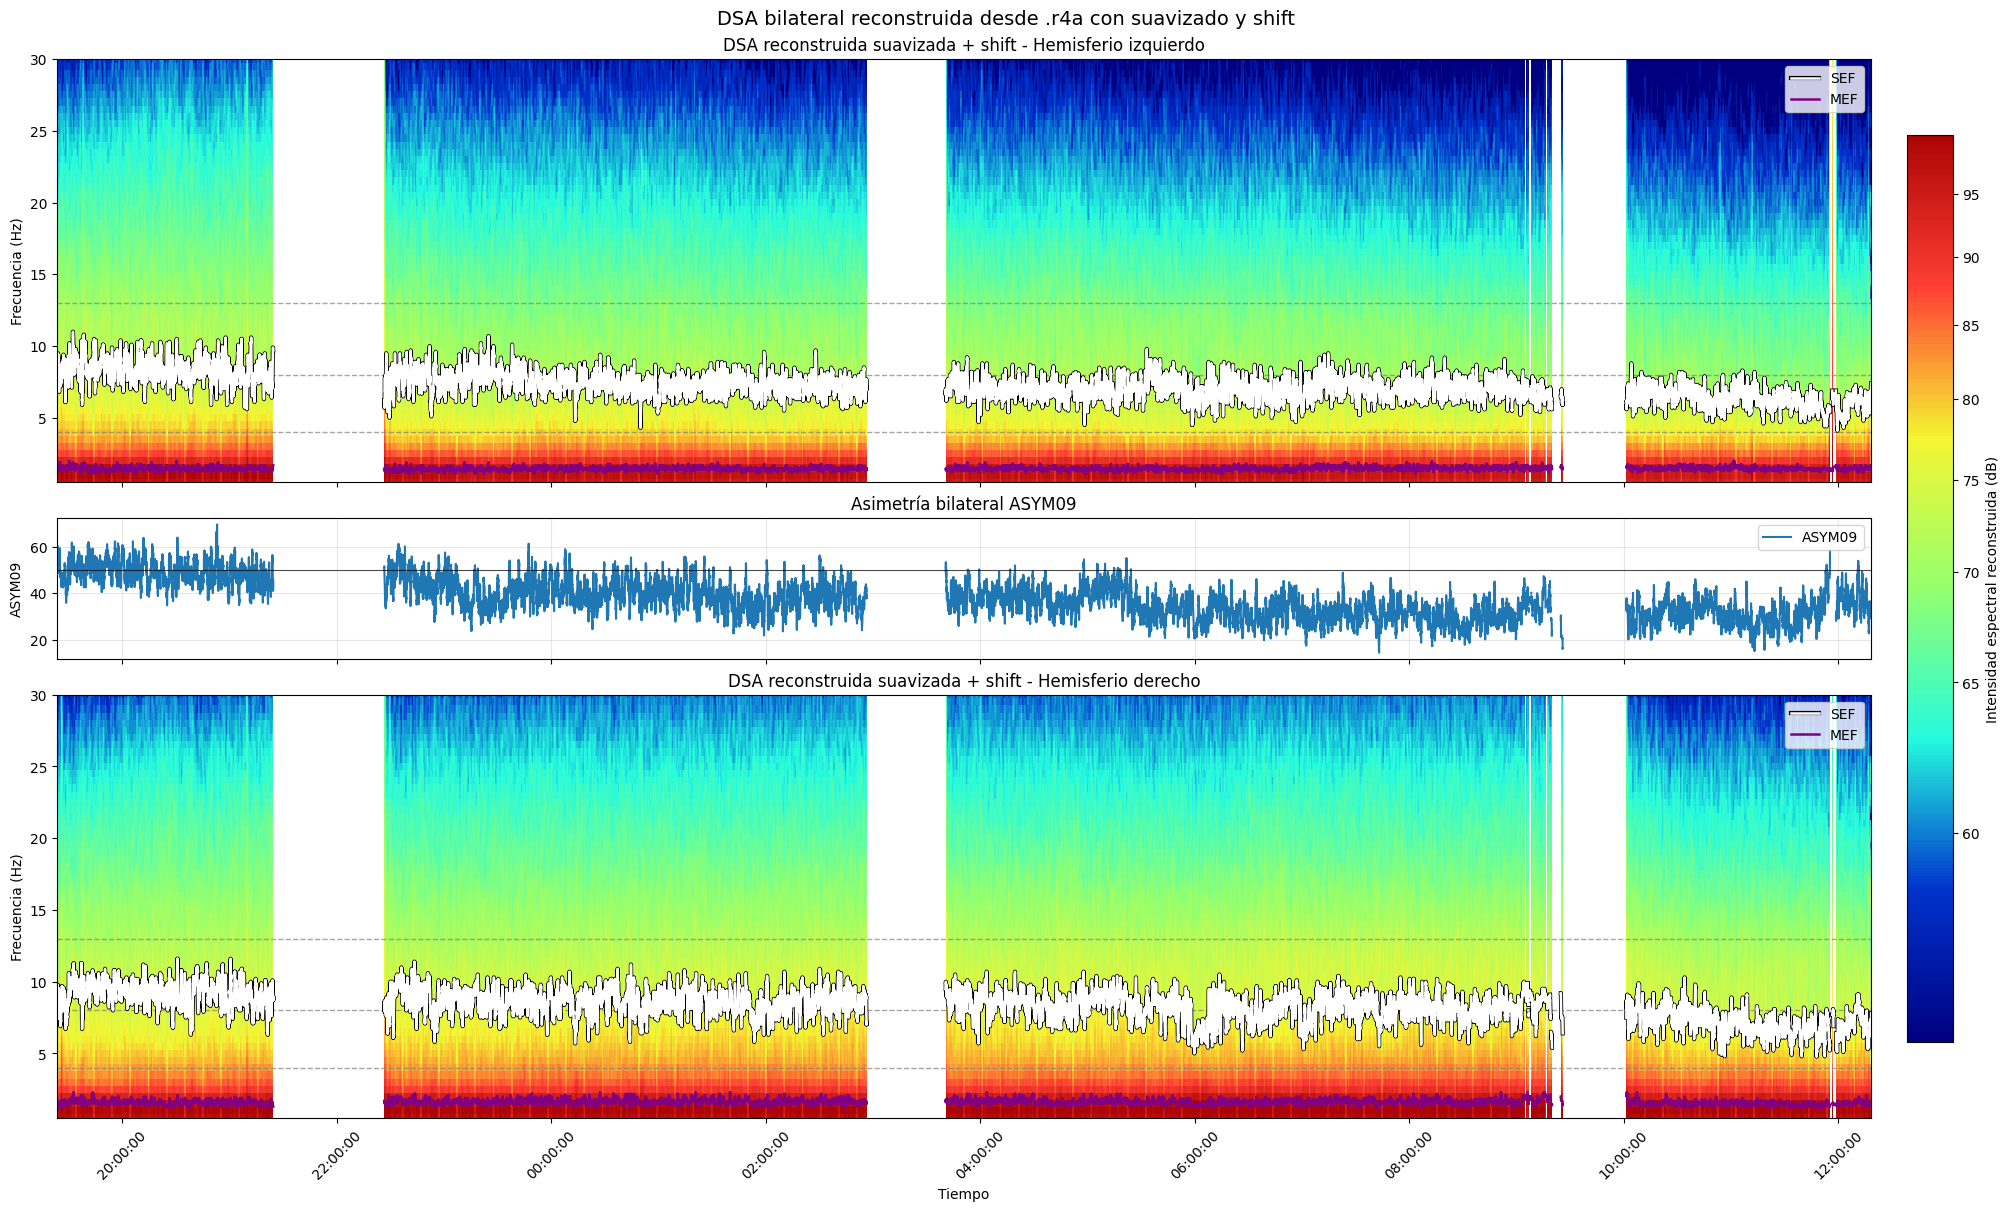

In [54]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=dsa_eeg_izq_suav_shift_full.columns.astype(float),
    matriz_izq=matriz_shift_izq,
    matriz_der=matriz_shift_der,
    norm=norm_shift_bilat,
    cmap=cmap_shift_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_total_bilat,
    mask_der=mask_total_bilat,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida suavizada + shift - Hemisferio izquierdo",
    titulo_der="DSA reconstruida suavizada + shift - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde .r4a con suavizado y shift",
    etiqueta_colorbar="Intensidad espectral reconstruida (dB)"
)

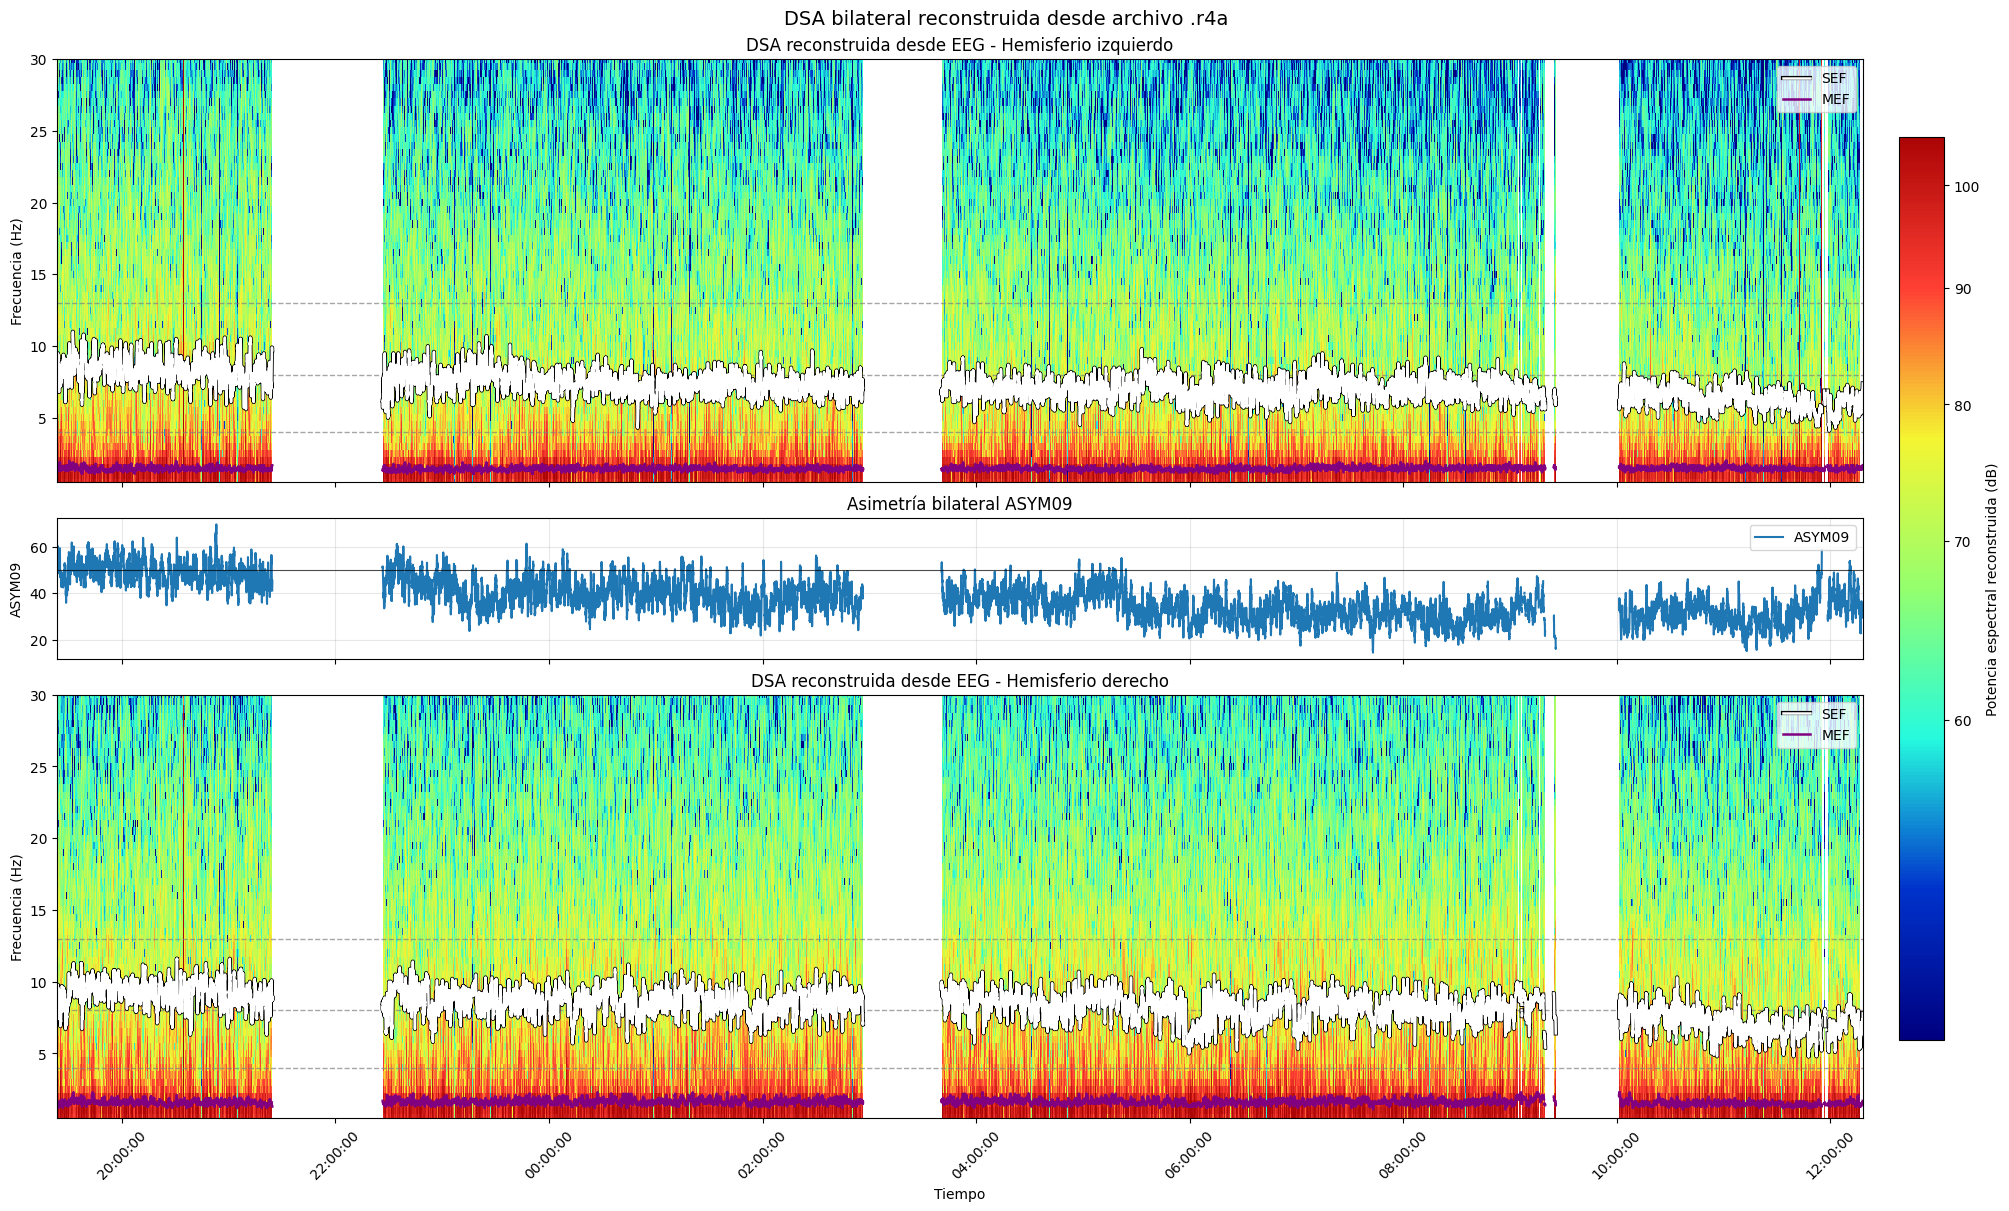

In [55]:
fig_eeg, axes_eeg = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=dsa_eeg_izq_plot.columns.astype(float),
    matriz_izq=matriz_eeg_izq,
    matriz_der=matriz_eeg_der,
    norm=norm_eeg_bilat,
    cmap=cmap_eeg_bilat,
    df_merge_izq=df_merge_eeg_izq,
    df_merge_der=df_merge_eeg_der,
    mask_izq=mask_total_bilat,
    mask_der=mask_total_bilat,
    asimetria=df_merge_eeg_izq["ASYM09"] if "ASYM09" in df_merge_eeg_izq.columns else None,
    titulo_izq="DSA reconstruida desde EEG - Hemisferio izquierdo",
    titulo_der="DSA reconstruida desde EEG - Hemisferio derecho",
    titulo_general="DSA bilateral reconstruida desde archivo .r4a",
    etiqueta_colorbar="Potencia espectral reconstruida (dB)"
)

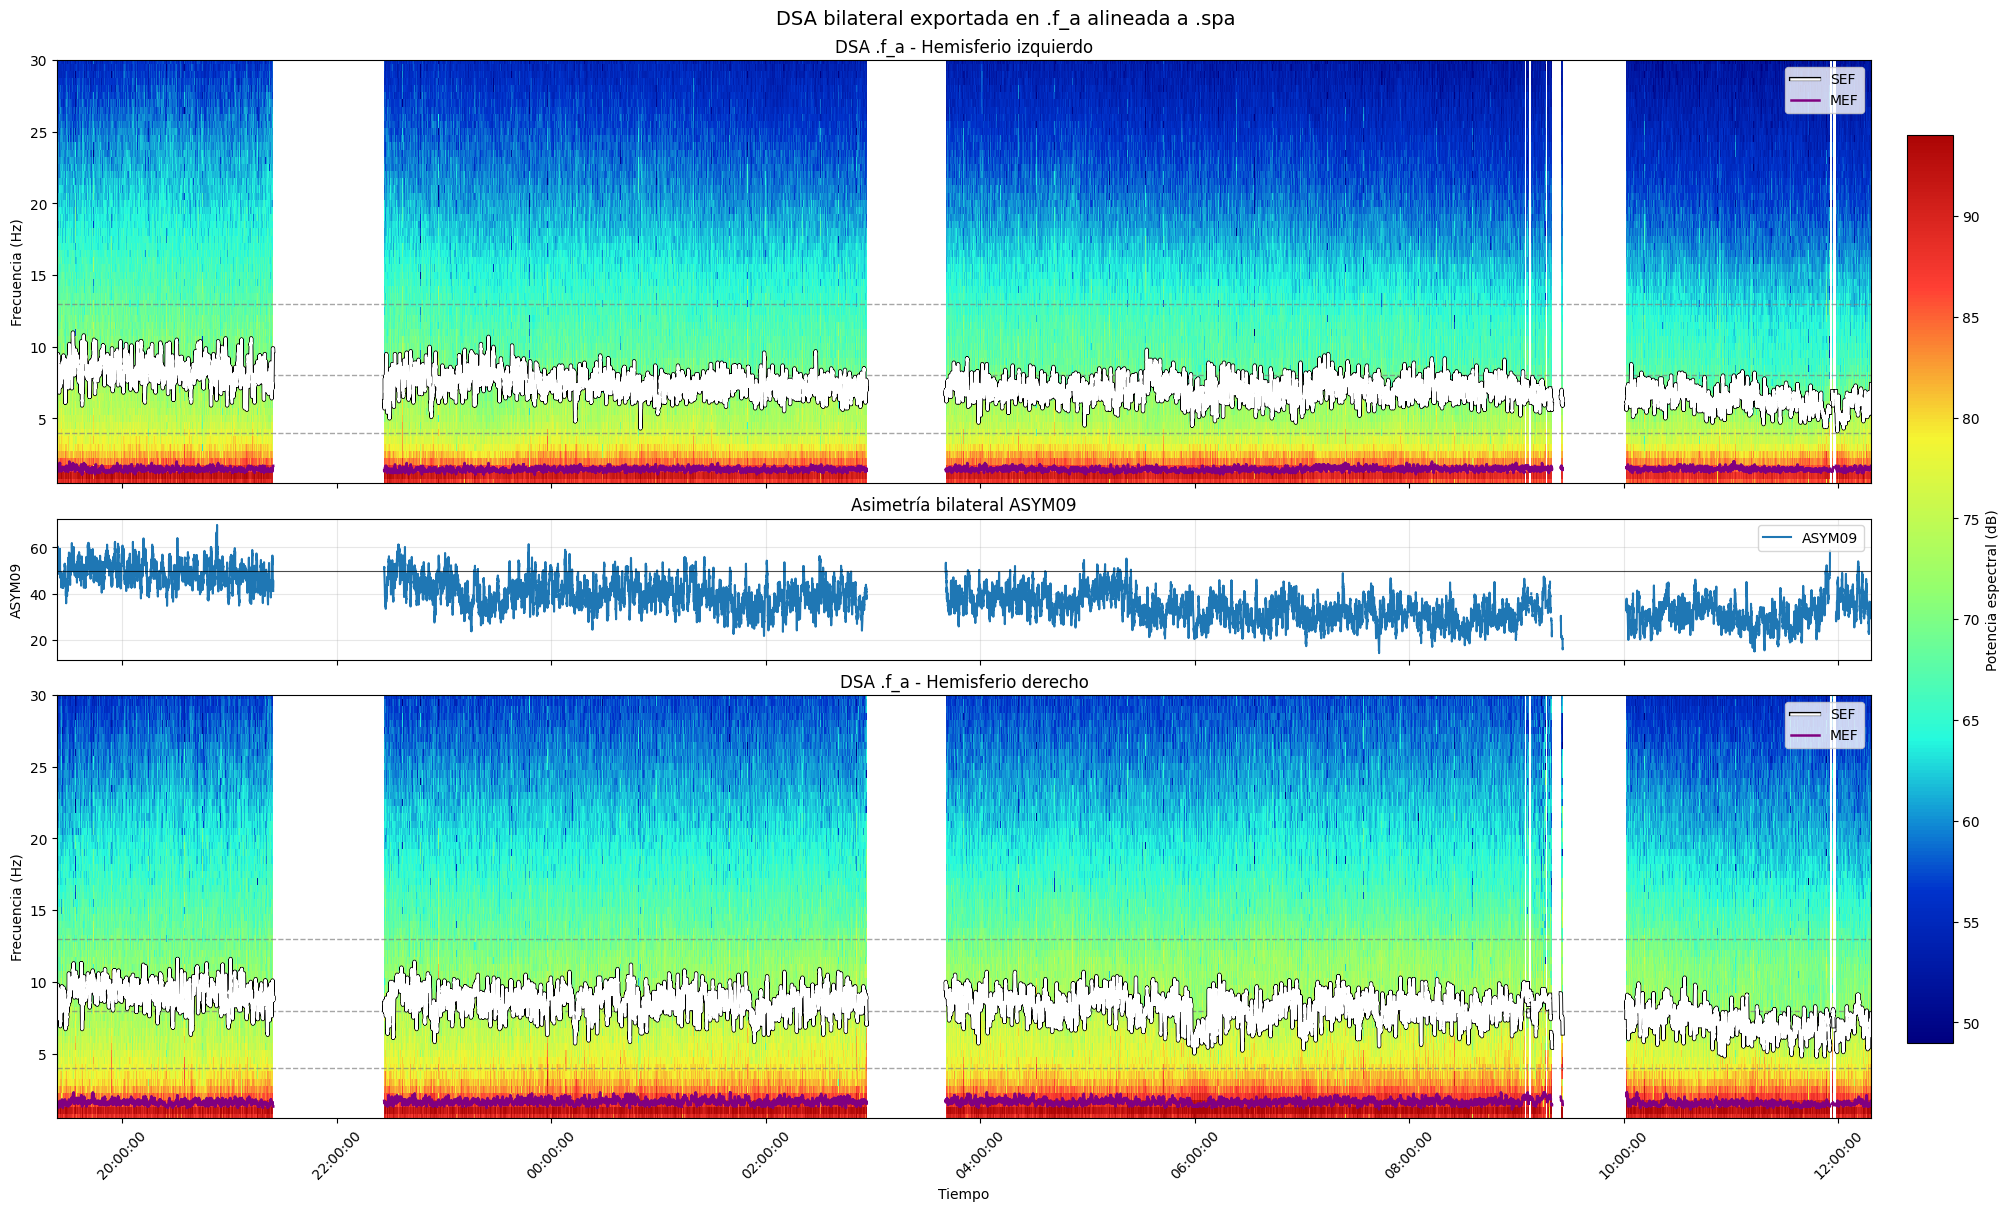

In [56]:
fig_fa, axes_fa = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=timeline_spa_bilat,
    frecuencias=frecuencias_fa,
    matriz_izq=matriz_fa_L,
    matriz_der=matriz_fa_R,
    norm=norm_fa_bilat,
    cmap=cmap_fa_bilat,
    df_merge_izq=df_merge_fa_L,
    df_merge_der=df_merge_fa_R,
    mask_izq=mask_total_fa_bilat,
    mask_der=mask_total_fa_bilat,
    asimetria=df_merge_fa_L["ASYM09"],
    titulo_izq="DSA .f_a - Hemisferio izquierdo",
    titulo_der="DSA .f_a - Hemisferio derecho",
    titulo_general="DSA bilateral exportada en .f_a alineada a .spa",
    etiqueta_colorbar="Potencia espectral (dB)"
)

In [ ]:
ruta_spa_bilat_h = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923/DH04301923/L04301923.spa"
df_spa_raw_h = fau.procesar_spa(ruta_spa_bilat_h)

df_spa_limpio_h = fun_dsa_b.limpiar_spa_bilateral(df_spa_raw_h)


display(df_spa_limpio_h.head())